In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
from one.api import ONE

In [2]:
from ibl_info.load_glm_hmm import run_glm_for_session

2024-09-17 18:20:08.577 | INFO     | ibl_info.config:<module>:11 - PROJ_ROOT path is: D:\personal\phD\code\information-decomposition\ibl-partial-info-decomp


In [4]:

eids_df = pd.read_csv('D:\personal\phD\code\information-decomposition\ibl-partial-info-decomp\data\processed\eids_to_analyse.csv')
one = ONE(base_url="https://openalyx.internationalbrainlab.org", password="international")
eids = eids_df.eid

Downloading: C:\Users\debot\Downloads\ONE\openalyx.internationalbrainlab.org\tmpnenn9jx3\cache.zip Bytes: 7407474


100%|██████████| 7.06431770324707/7.06431770324707 [00:01<00:00,  7.03it/s]


In [26]:
df = run_glm_for_session(eids[1], K=2)

K = 2
-------
f312aaec-3b6f-44b3-86b4-3a0c119c0438 --> CSHL058


C:\Users\debot\Downloads\ONE\alyx.internationalbrainlab.org\churchlandlab\Subjects\CSHL058\2020-07-07\001\alf\_ibl_trials.goCueTrigger_times.npy: 100%|██████████| 5.14k/5.14k [00:00<00:00, 19.4kB/s]
C:\Users\debot\Downloads\ONE\alyx.internationalbrainlab.org\churchlandlab\Subjects\CSHL058\2020-07-07\001\alf\_ibl_trials.intervals_bpod.npy: 100%|██████████| 10.1k/10.1k [00:00<00:00, 28.8kB/s]
C:\Users\debot\Downloads\ONE\alyx.internationalbrainlab.org\churchlandlab\Subjects\CSHL058\2020-07-07\001\alf\_ibl_trials.table.pqt: 100%|██████████| 51.7k/51.7k [00:00<00:00, 138kB/s]
C:\Users\debot\Downloads\ONE\alyx.internationalbrainlab.org\churchlandlab\Subjects\CSHL058\2020-07-07\001\alf\_ibl_trials.quiescencePeriod.npy: 100%|██████████| 5.14k/5.14k [00:00<00:00, 15.9kB/s]
C:\Users\debot\Downloads\ONE\alyx.internationalbrainlab.org\churchlandlab\Subjects\CSHL058\2020-07-07\001\alf\_ibl_trials.stimOff_times.npy: 100%|██████████| 5.14k/5.14k [00:00<00:00, 16.1kB/s]

Trials table for this session not found
Using saved design matrix and individual fit parameters
Computing GLM-HMM posterior


In [27]:
K = 2

In [40]:
biased_df = df[~(df.probabilityLeft==0.5)]

In [41]:
glm_fit = np.concatenate(biased_df[f"glm-hmm_{K}"].values).reshape(-1, K)

In [42]:
glm_fit

array([[0.01618561, 0.98381439],
       [0.02041674, 0.97958326],
       [0.02610748, 0.97389252],
       ...,
       [0.06331981, 0.93668019],
       [0.05802773, 0.94197227],
       [0.05714314, 0.94285686]])

In [43]:
state_0 = np.argmax(glm_fit, axis=1) == 0
state_1 = np.argmax(glm_fit, axis=1) == 1

In [45]:
state_0_trials = biased_df[state_0]
state_1_trials = biased_df[state_1]

In [46]:
np.sum(state_0_trials['feedbackType']==1)/len(state_0_trials['feedbackType'])

0.7222222222222222

In [47]:
np.sum(state_1_trials['feedbackType']==1)/len(state_1_trials['feedbackType'])

0.8243243243243243

<Axes: >

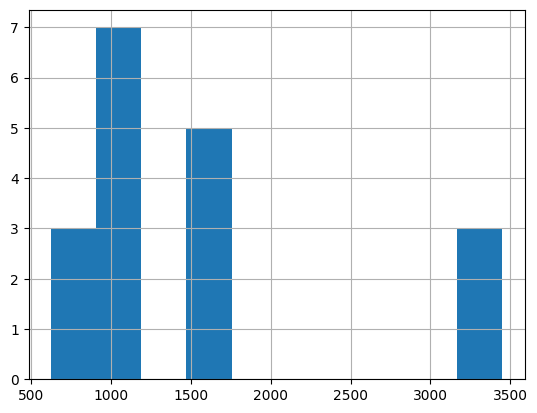

In [48]:
state_0_trials['response_times'].hist()

<Axes: >

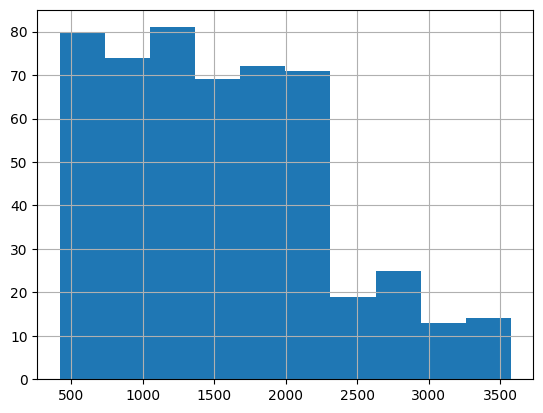

In [49]:
state_1_trials['response_times'].hist()

In [54]:
state_0_trials.index

Index([144, 145, 146, 247, 248, 249, 250, 251, 252, 253, 371, 372, 373, 374,
       375, 614, 615, 616],
      dtype='int64')

In [56]:
state_1_trials.index.shape

(518,)